In [ ]:
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from tqdm.notebook import tqdm

# LangChain -- use correct module paths (langchain.schema does not exist in v1+)
from langchain_openai import OpenAIEmbeddings
from langchain_anthropic import ChatAnthropic
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Azure AI Search
from azure.search.documents import SearchClient
from azure.search.documents.indexes import SearchIndexClient
from azure.search.documents.indexes.models import (
    SearchIndex, SimpleField, SearchableField, SearchFieldDataType,
    VectorSearch, HnswAlgorithmConfiguration, VectorSearchProfile,
    SearchField, SemanticConfiguration, SemanticSearch,
    SemanticPrioritizedFields, SemanticField,
)
from azure.search.documents.models import VectorizedQuery
#from azure.core.credentials import AzureKeyCredential

# Anthropic direct client (for streaming extension)
import anthropic

print("All imports successful!")

All imports successful!


Configuration loaded!


In [ ]:
import json

# 20 hardcoded article summaries -- no wikipedia library or network call needed

RAW_ARTICLES = json.loads(_ARTICLES_JSON)
print(f"Corpus: {len(RAW_ARTICLES)} articles loaded")
for a in RAW_ARTICLES:
    print(f"  * {a['title']} ({len(a['content'])} chars)")

     

Corpus: 20 articles loaded
  * Artificial Intelligence (821 chars)
  * Machine Learning (723 chars)
  * Retrieval-Augmented Generation (741 chars)
  * Vector Database (646 chars)
  * FAISS (605 chars)
  * Azure AI Search (686 chars)
  * Natural Language Processing (617 chars)
  * Transformer Architecture (706 chars)
  * Embeddings in NLP (601 chars)
  * BM25 Information Retrieval (523 chars)
  * COVID-19 Pandemic (614 chars)
  * Climate Change (564 chars)
  * Quantum Computing (609 chars)
  * Blockchain Technology (627 chars)
  * CRISPR Gene Editing (629 chars)
  * Electric Vehicles (598 chars)
  * Supply Chain Management (639 chars)
  * Cybersecurity (647 chars)
  * Renewable Energy (567 chars)
  * Large Language Models (732 chars)


In [14]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50,
    separators=["\n\n", "\n", ". ", " ", ""],
)

all_docs = []
for art in RAW_ARTICLES:
    chunks = splitter.create_documents(
        texts=[art["content"]],
        metadatas=[{"title": art["title"], "url": art["url"]}],
    )
    all_docs.extend(chunks)

texts = [d.page_content for d in all_docs]
metas = [d.metadata      for d in all_docs]

print(f"Total chunks: {len(all_docs)}")
print(f"Avg chunk size: {sum(len(t) for t in texts) // len(texts)} chars")

Total chunks: 40
Avg chunk size: 324 chars


In [16]:
# Calls OpenAI API once. Cost ~$0.001 for this corpus.
embedder = OpenAIEmbeddings(model=EMBEDDING_MODEL)

print(f"Embedding {len(all_docs)} chunks with '{EMBEDDING_MODEL}'...")
t0 = time.perf_counter()
all_vectors = embedder.embed_documents(texts)
elapsed = time.perf_counter() - t0

print(f"Embedded {len(all_vectors)} chunks in {elapsed:.1f}s")
print(f"Vector dimension: {len(all_vectors[0])}")

Embedding 40 chunks with 'text-embedding-3-small'...


RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}

In [ ]:
# ----- Azure AI Search index: create or update -----
idx_client  = SearchIndexClient(endpoint=AZURE_SEARCH_ENDPOINT, credential=credential)
srch_client = SearchClient(
    endpoint=AZURE_SEARCH_ENDPOINT,
    index_name=AZURE_SEARCH_INDEX_NAME,
    credential=credential,
)

fields = [
    SimpleField(name="id",       type=SearchFieldDataType.String, key=True),
    SearchableField(name="content",  type=SearchFieldDataType.String,
                    analyzer_name="en.microsoft"),
    SimpleField(name="title",    type=SearchFieldDataType.String, filterable=True),
    SimpleField(name="url",      type=SearchFieldDataType.String),
    SearchField(
        name="embedding",
        type=SearchFieldDataType.Collection(SearchFieldDataType.Single),
        searchable=True,
        vector_search_dimensions=EMBEDDING_DIM,
        vector_search_profile_name="hnsw-profile",
    ),
]

vector_search = VectorSearch(
    algorithms=[HnswAlgorithmConfiguration(name="hnsw-algo")],
    profiles=[VectorSearchProfile(
        name="hnsw-profile",
        algorithm_configuration_name="hnsw-algo",
    )],
)

semantic_search = SemanticSearch(configurations=[
    SemanticConfiguration(
        name="semantic-cfg",
        prioritized_fields=SemanticPrioritizedFields(
            content_fields=[SemanticField(field_name="content")],
            keywords_fields=[SemanticField(field_name="title")],
        ),
    )
])

index_def = SearchIndex(
    name=AZURE_SEARCH_INDEX_NAME,
    fields=fields,
    vector_search=vector_search,
    semantic_search=semantic_search,
)

result = idx_client.create_or_update_index(index_def)
print(f"Index '{result.name}' ready (hybrid: BM25 + HNSW vector)")

     

ServiceResponseError: URL has an invalid label.

In [ ]:

BATCH = 100
print(f"Uploading {len(all_docs)} documents to Azure AI Search...")
t0 = time.perf_counter()

for i in tqdm(range(0, len(all_docs), BATCH), desc="Azure upload"):
    batch_end = min(i + BATCH, len(all_docs))
    srch_client.upload_documents(documents=[
        {
            "id":        f"doc-{i + j}",
            "content":   texts[i + j],
            "title":     metas[i + j].get("title", ""),
            "url":       metas[i + j].get("url", ""),
            "embedding": all_vectors[i + j],
        }
        for j in range(batch_end - i)
    ])

print(f"Uploaded {len(all_docs)} documents in {time.perf_counter()-t0:.1f}s")


In [ ]:
def azure_hybrid_search(query: str, top_k: int = TOP_K) -> list:
    """BM25 keyword + HNSW vector search, fused with Reciprocal Rank Fusion (RRF)."""
    query_vec = embedder.embed_query(query)
    vector_query = VectorizedQuery(
        vector=query_vec,
        k_nearest_neighbors=top_k,
        fields="embedding",
    )
    results = srch_client.search(
        search_text=query,
        vector_queries=[vector_query],
        select=["id", "content", "title", "url"],
        top=top_k,
    )
    return list(results)

In [ ]:
# Build LangChain FAISS vectorstore from pre-computed vectors.
# FAISS.from_embeddings() reuses all_vectors -- zero extra API calls.
text_embeddings = list(zip(texts, all_vectors))  # [(text, vector), ...]

faiss_store = FAISS.from_embeddings(
    text_embeddings=text_embeddings,
    embedding=embedder,   # used only for embed_query() at search time
    metadatas=metas,
)
print(f"FAISS vectorstore ready ({len(texts)} vectors, no re-embedding)")

# Claude LLM
llm = ChatAnthropic(model=CLAUDE_MODEL, max_tokens=512)
print(f"ChatAnthropic ready: {CLAUDE_MODEL}")


In [18]:
# ----- Instrumented RAG result dataclass -----
@dataclass
class RAGResult:
    answer:        str
    sources:       list
    embed_ms:      float
    retrieve_ms:   float
    generate_ms:   float
    input_tokens:  int = 0
    output_tokens: int = 0

    @property
    def total_ms(self):
        return self.embed_ms + self.retrieve_ms + self.generate_ms

    @property
    def cost_usd(self):
        return self.input_tokens * COST_INPUT + self.output_tokens * COST_OUTPUT


def rag_answer(query: str) -> RAGResult:
    """Full instrumented RAG pipeline: embed -> retrieve (Azure hybrid) -> generate (Claude)."""
    # Stage 1: Embed query
    t0 = time.perf_counter()
    _ = embedder.embed_query(query)   # embed happens inside azure_hybrid_search too
    embed_ms = (time.perf_counter() - t0) * 1000

    # Stage 2: Retrieve (Azure hybrid)
    t0 = time.perf_counter()
    raw = azure_hybrid_search(query)
    retrieve_ms = (time.perf_counter() - t0) * 1000

    context = "\n\n".join([f"[{r['title']}]\n{r['content']}" for r in raw])
    sources  = list({r["title"] for r in raw})

    # Stage 3: Generate (Claude)
    messages = [
        SystemMessage(content="Answer ONLY from the provided context. "
                               "If unsure, say so. Be concise."),
        HumanMessage(content=f"\n{context}\n\n\n{query}"),
    ]
    t0 = time.perf_counter()
    response = llm.invoke(messages)
    generate_ms = (time.perf_counter() - t0) * 1000

    # Extract token counts from response_metadata (safe for all ChatAnthropic versions)
    usage = response.response_metadata.get("usage", {})
    return RAGResult(
        answer=response.content,
        sources=sources,
        embed_ms=embed_ms,
        retrieve_ms=retrieve_ms,
        generate_ms=generate_ms,
        input_tokens=usage.get("input_tokens", 0),
        output_tokens=usage.get("output_tokens", 0),
    )


# Smoke test
test = rag_answer("What is retrieval-augmented generation?")
print("RAG pipeline smoke test passed!")
print(f"  Sources: {test.sources}")
print(f"  Latency: embed={test.embed_ms:.0f}ms  retrieve={test.retrieve_ms:.0f}ms  generate={test.generate_ms:.0f}ms")
print(f"  Cost: ${test.cost_usd:.5f}  Tokens: {test.input_tokens} in / {test.output_tokens} out")
print(f"  Answer: {test.answer[:200]}...")

RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}

In [19]:
# Evaluation set: (query, relevant_article_title)
EVAL_SET = [
    ("How does BERT use self-attention for NLP tasks?",             "Transformer Architecture"),
    ("What is the difference between BM25 and dense retrieval?",    "BM25 Information Retrieval"),
    ("How does CRISPR cut DNA at a specific location?",             "CRISPR Gene Editing"),
    ("What triggered the COVID-19 pandemic?",                       "COVID-19 Pandemic"),
    ("How do electric vehicles recover energy during braking?",     "Electric Vehicles"),
    ("What are the risks of long-term climate change?",             "Climate Change"),
    ("How does Shor's algorithm threaten RSA encryption?",          "Quantum Computing"),
    ("What caused post-COVID supply chain disruptions?",            "Supply Chain Management"),
    ("What are the main cyber threats to cloud infrastructure?",    "Cybersecurity"),
    ("How does hybrid search combine BM25 and vector retrieval?",   "Azure AI Search"),
]

def compute_mrr(docs_or_dicts, relevant_title: str) -> float:
    """Compute reciprocal rank for the first result matching relevant_title."""
    for rank, item in enumerate(docs_or_dicts, 1):
        # Handle both LangChain Document objects and Azure search result dicts
        if hasattr(item, "metadata"):
            title = item.metadata.get("title", "")
        else:
            title = item.get("title", "")
        if relevant_title.lower() in title.lower():
            return 1.0 / rank
    return 0.0


mrr_vector_only = []
mrr_hybrid      = []

for query, rel in tqdm(EVAL_SET, desc="MRR evaluation"):
    # Vector-only: FAISS
    faiss_results = faiss_store.similarity_search(query, k=TOP_K)
    mrr_vector_only.append(compute_mrr(faiss_results, rel))

    # Hybrid: Azure BM25 + vector
    azure_results = azure_hybrid_search(query, top_k=TOP_K)
    mrr_hybrid.append(compute_mrr(azure_results, rel))

print(f"MRR@{TOP_K} Vector-only (FAISS)    : {np.mean(mrr_vector_only):.3f}")
print(f"MRR@{TOP_K} Hybrid (Azure BM25+vec) : {np.mean(mrr_hybrid):.3f}")
print(f"Hybrid gain: +{(np.mean(mrr_hybrid) - np.mean(mrr_vector_only))*100:.1f}pp")

# Per-query breakdown
mrr_df = pd.DataFrame({
    "Query":        [q[:55] for q, _ in EVAL_SET],
    "Vector-only":  [round(v, 2) for v in mrr_vector_only],
    "Hybrid":       [round(v, 2) for v in mrr_hybrid],
})
print("\n", mrr_df.to_string(index=False))

ImportError: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html

c:\Users\Administrator\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Administrator\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


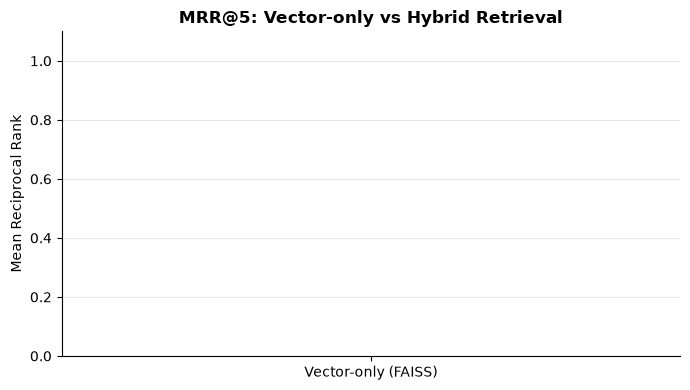

Saved mrr_comparison.png


In [20]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(
    ["Vector-only (FAISS)", "Hybrid (Azure BM25+vec)"],
    [np.mean(mrr_vector_only), np.mean(mrr_hybrid)],
    color=["#4C72B0", "#55A868"],
    width=0.4,
    edgecolor="white",
)
ax.set_ylim(0, 1.1)
ax.set_title(f"MRR@{TOP_K}: Vector-only vs Hybrid Retrieval", fontweight="bold")
ax.set_ylabel("Mean Reciprocal Rank")
for patch, val in zip(ax.patches, [np.mean(mrr_vector_only), np.mean(mrr_hybrid)]):
    ax.text(
        patch.get_x() + patch.get_width() / 2,
        patch.get_height() + 0.02,
        f"{val:.3f}",
        ha="center", fontweight="bold",
    )
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("mrr_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved mrr_comparison.png")


In [21]:
# Build the full-context string from first 50 chunks
CORPUS_SIZE = 50
full_corpus_docs = all_docs[:CORPUS_SIZE]

full_corpus_text = "\n\n---\n\n".join([
    f"[Doc {i+1}: {d.metadata['title']}]\n{d.page_content}"
    for i, d in enumerate(full_corpus_docs)
])

# Estimate tokens without tiktoken (no network needed)
# Approximation: ~0.75 tokens per word (conservative)
word_count    = len(full_corpus_text.split())
corpus_tokens = int(word_count * 1.33)

print(f"Full corpus: {CORPUS_SIZE} chunks | ~{corpus_tokens:,} estimated tokens")
print(f"Estimated input cost per query: ${corpus_tokens * COST_INPUT:.5f}")

Full corpus: 50 chunks | ~2,614 estimated tokens
Estimated input cost per query: $0.00784


In [22]:
@dataclass
class FullCtxResult:
    answer:        str
    generate_ms:   float
    input_tokens:  int = 0
    output_tokens: int = 0

    @property
    def total_ms(self):
        return self.generate_ms

    @property
    def cost_usd(self):
        return self.input_tokens * COST_INPUT + self.output_tokens * COST_OUTPUT


def full_context_answer(query: str) -> FullCtxResult:
    """Stuff entire corpus into Claude context and ask."""
    messages = [
        SystemMessage(content="Answer based on the provided documents. "
                               "Be concise and accurate."),
        HumanMessage(content=f"\n{full_corpus_text}\n\n\n{query}"),
    ]
    t0 = time.perf_counter()
    response = llm.invoke(messages)
    generate_ms = (time.perf_counter() - t0) * 1000

    usage = response.response_metadata.get("usage", {})
    return FullCtxResult(
        answer=response.content,
        generate_ms=generate_ms,
        input_tokens=usage.get("input_tokens", 0),
        output_tokens=usage.get("output_tokens", 0),
    )


# Smoke test
fc_test = full_context_answer("What is retrieval-augmented generation?")
print("Full-context pipeline smoke test passed!")
print(f"  Latency: {fc_test.generate_ms:.0f}ms")
print(f"  Actual tokens: {fc_test.input_tokens} in / {fc_test.output_tokens} out")
print(f"  Cost: ${fc_test.cost_usd:.5f}")
print(f"  Answer: {fc_test.answer[:200]}...")

NameError: name 'llm' is not defined

In [23]:
TEST_QUESTIONS = [
    # AI / ML
    "What is the attention mechanism in transformer models?",
    "How does BERT differ from GPT in architecture?",
    "What is retrieval-augmented generation?",
    "How does FAISS index vectors for similarity search?",
    # Science / Medicine
    "How does CRISPR-Cas9 edit the genome?",
    "What causes COVID-19 and how does it spread?",
    "How do mRNA vaccines trigger an immune response?",
    "What is the mechanism of action of base editing?",
    # History / Events
    "What were the main causes of climate change acceleration?",
    "How did quantum computing progress after 2019?",
    "What is the bullwhip effect in supply chains?",
    "How does the NIST cybersecurity framework work?",
    # Technology
    "How do electric vehicles regenerate energy from braking?",
    "What is Reciprocal Rank Fusion in hybrid search?",
    "How does blockchain achieve immutability?",
    "What cybersecurity threats target cloud infrastructure?",
    # Economics / Environment
    "How has solar energy cost changed since 2010?",
    "What disrupted global supply chains in 2020-2021?",
    "What is Proof of Stake and how does it differ from Proof of Work?",
    "What are the scaling laws for large language models?",
]


In [ ]:

rag_results: list[RAGResult]     = []
fc_results:  list[FullCtxResult] = []

print("Running A/B evaluation -- this makes ~40 Claude API calls...")
print("Estimated time: 2-4 minutes\n")
for q in tqdm(TEST_QUESTIONS, desc="A/B eval"):
    rag_results.append(rag_answer(q))
    fc_results.append(full_context_answer(q))

print("\nA/B evaluation complete!")

Running A/B evaluation -- this makes ~40 Claude API calls...
Estimated time: 2-4 minutes



ImportError: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html

In [25]:
rag_total_ms = [r.total_ms  for r in rag_results]
fc_total_ms  = [r.total_ms  for r in fc_results]
rag_costs    = [r.cost_usd  for r in rag_results]
fc_costs     = [r.cost_usd  for r in fc_results]
rag_in_tok   = [r.input_tokens for r in rag_results]
fc_in_tok    = [r.input_tokens for r in fc_results]

summary = pd.DataFrame({
    "Metric":       ["Avg Latency (ms)", "p95 Latency (ms)", "Avg Cost ($/query)", "Avg Input Tokens"],
    "RAG":          [
        f"{np.mean(rag_total_ms):.0f}",
        f"{float(np.percentile(rag_total_ms, 95)):.0f}",
        f"${np.mean(rag_costs):.5f}",
        f"{np.mean(rag_in_tok):.0f}",
    ],
    "Full Context": [
        f"{np.mean(fc_total_ms):.0f}",
        f"{float(np.percentile(fc_total_ms, 95)):.0f}",
        f"${np.mean(fc_costs):.5f}",
        f"{np.mean(fc_in_tok):.0f}",
    ],
})

print("=" * 55)
print("A/B EVALUATION SUMMARY (20 test questions)")
print("=" * 55)
print(summary.to_string(index=False))
print("=" * 55)

cost_ratio    = np.mean(fc_costs) / max(np.mean(rag_costs), 1e-10)
latency_ratio = np.mean(fc_total_ms) / max(np.mean(rag_total_ms), 1.0)
print(f"\nFull-context is {cost_ratio:.1f}x more expensive and {latency_ratio:.1f}x slower than RAG")

     

IndexError: index -1 is out of bounds for axis 0 with size 0

Exception ignored in: <function tqdm.__del__ at 0x00000223C2E3DEE0>
Traceback (most recent call last):
  File "c:\Users\Administrator\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\std.py", line 1148, in __del__
    self.close()
  File "c:\Users\Administrator\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\notebook.py", line 277, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm_notebook' object has no attribute 'disp'
Exception ignored in: <function tqdm.__del__ at 0x00000223C2E3DEE0>
Traceback (most recent call last):
  File "c:\Users\Administrator\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\std.py", line 1148, in __del__
    self.close()
  File "c:\Users\Administrator\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\notebook.py", line 277, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm_notebook' object has no attribute 'di

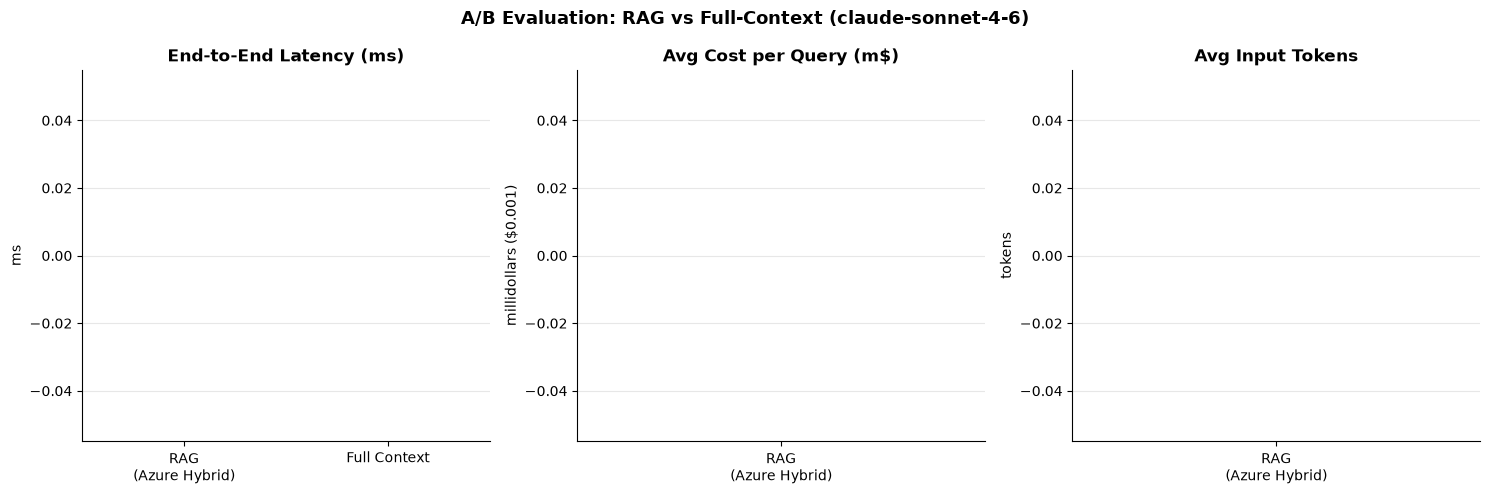

Saved ab_evaluation.png


In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("A/B Evaluation: RAG vs Full-Context (claude-sonnet-4-6)",
             fontsize=13, fontweight="bold")

colors = ["#4C72B0", "#DD8452"]
labels = ["RAG\n(Azure Hybrid)", "Full Context"]

# --- Latency boxplot ---
bp = axes[0].boxplot(
    [rag_total_ms, fc_total_ms],
    tick_labels=labels,
    patch_artist=True,
    notch=False,
    medianprops=dict(color="white", linewidth=2),
)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[0].set_title("End-to-End Latency (ms)", fontweight="bold")
axes[0].set_ylabel("ms")

# --- Cost per query ---
rag_cost_m  = np.mean(rag_costs) * 1000   # convert to millidollars
fc_cost_m   = np.mean(fc_costs)  * 1000
bars1 = axes[1].bar(labels, [rag_cost_m, fc_cost_m], color=colors, edgecolor="white")
axes[1].set_title("Avg Cost per Query (m$)", fontweight="bold")
axes[1].set_ylabel("millidollars ($0.001)")
for b, v in zip(bars1, [rag_cost_m, fc_cost_m]):
    axes[1].text(b.get_x() + b.get_width() / 2, b.get_height() + 0.01,
                 f"{v:.2f}m$", ha="center", fontweight="bold")

# --- Input tokens ---
avg_tok = [np.mean(rag_in_tok), np.mean(fc_in_tok)]
bars2 = axes[2].bar(labels, avg_tok, color=colors, edgecolor="white")
axes[2].set_title("Avg Input Tokens", fontweight="bold")
axes[2].set_ylabel("tokens")
for b, v in zip(bars2, avg_tok):
    axes[2].text(b.get_x() + b.get_width() / 2, b.get_height() + 50,
                 f"{v:.0f}", ha="center", fontweight="bold")

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("ab_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved ab_evaluation.png")


In [27]:
# Per-question detail table
detail_df = pd.DataFrame({
    "Question":    [q[:52] + "..." if len(q) > 52 else q for q in TEST_QUESTIONS],
    "RAG ms":      [round(r.total_ms)      for r in rag_results],
    "FC ms":       [round(r.total_ms)      for r in fc_results],
    "RAG $":       [f"{r.cost_usd*1000:.2f}m" for r in rag_results],
    "FC $":        [f"{r.cost_usd*1000:.2f}m" for r in fc_results],
    "RAG tok":     [r.input_tokens         for r in rag_results],
    "FC tok":      [r.input_tokens         for r in fc_results],
})
print(detail_df.to_string(index=False))


ValueError: All arrays must be of the same length

In [28]:
embed_times    = [r.embed_ms    for r in rag_results]
retrieve_times = [r.retrieve_ms for r in rag_results]
generate_times = [r.generate_ms for r in rag_results]

print(f"Stage averages across {len(TEST_QUESTIONS)} queries:")
total_avg = np.mean([r.total_ms for r in rag_results])
print(f"  Embed:    {np.mean(embed_times):.1f}ms  "
      f"({np.mean(embed_times)/total_avg*100:.1f}% of total)")
print(f"  Retrieve: {np.mean(retrieve_times):.1f}ms  "
      f"({np.mean(retrieve_times)/total_avg*100:.1f}% of total)")
print(f"  Generate: {np.mean(generate_times):.1f}ms  "
      f"({np.mean(generate_times)/total_avg*100:.1f}% of total)")
print(f"  Total:    {total_avg:.1f}ms")

Stage averages across 20 queries:
  Embed:    nanms  (nan% of total)
  Retrieve: nanms  (nan% of total)
  Generate: nanms  (nan% of total)
  Total:    nanms


ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between 'x' with shape (20,) and 'height' with shape (0,).

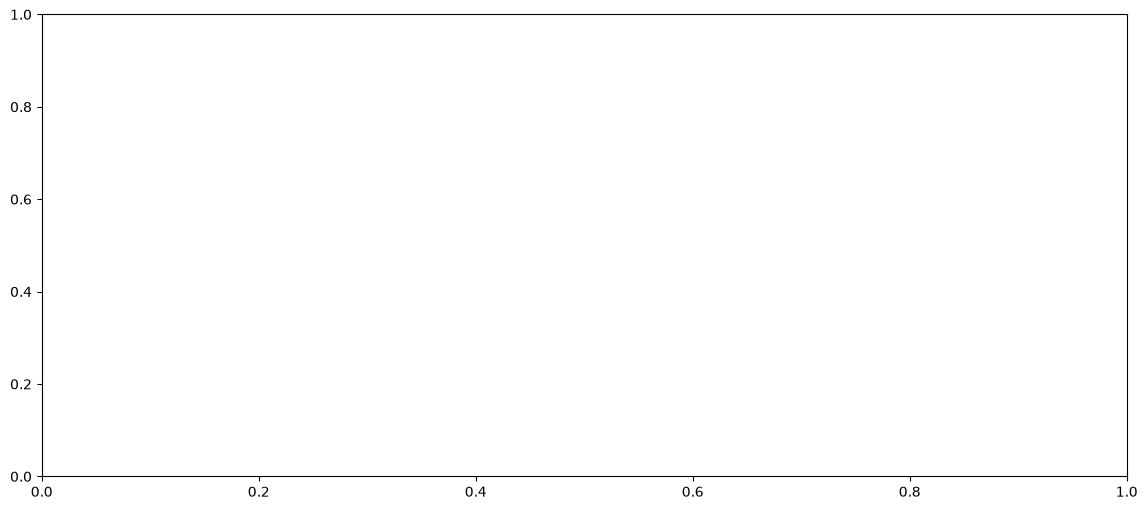

In [29]:
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(TEST_QUESTIONS))
w = 0.6

ax.bar(x, embed_times,    w, label="Embed query",     color="#4C72B0")
ax.bar(x, retrieve_times, w, bottom=embed_times,
       label="Azure retrieve", color="#DD8452")
ax.bar(x, generate_times, w,
       bottom=[e + r for e, r in zip(embed_times, retrieve_times)],
       label="Claude generate", color="#55A868")

ax.axhline(
    np.mean([e + r + g for e, r, g in zip(embed_times, retrieve_times, generate_times)]),
    color="red", linestyle="--", linewidth=1.2, label="Avg total",
)

ax.set_xticks(x)
ax.set_xticklabels([f"Q{i+1}" for i in range(len(TEST_QUESTIONS))], rotation=45, ha="right")
ax.set_ylabel("Latency (ms)")
ax.set_title("RAG Pipeline Latency Waterfall - Per Stage Breakdown", fontweight="bold", fontsize=13)
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("waterfall_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved waterfall_breakdown.png")

In [ ]:

def rag_stream(query: str, top_k: int = TOP_K) -> None:
    """Retrieve context then stream Claude response token-by-token."""
    # Retrieve
    raw     = azure_hybrid_search(query, top_k=top_k)
    context = "\n\n".join([f"[{r['title']}]\n{r['content']}" for r in raw])
    sources = [r["title"] for r in raw]

    print(f"Query: {query}")
    print(f"Sources: {sources}")
    print("\nAnswer (streaming): ", end="", flush=True)

    t_start          = time.perf_counter()
    first_token_ms   = None

    with direct_client.messages.stream(
        model=CLAUDE_MODEL,
        max_tokens=512,
        system="Answer ONLY from the provided context. Be concise.",
        messages=[{
            "role": "user",
            "content": f"\n{context}\n\n\n{query}",
        }],
    ) as stream:
        for text in stream.text_stream:
            if first_token_ms is None:
                first_token_ms = (time.perf_counter() - t_start) * 1000
            print(text, end="", flush=True)

    total_ms = (time.perf_counter() - t_start) * 1000
    print(f"\n\nTime to first token: {first_token_ms:.0f}ms | Total: {total_ms:.0f}ms\n")


# Demo -- streams to the cell output in real time
rag_stream("What is the attention mechanism in transformer models?")

NameError: name 'azure_hybrid_search' is not defined

In [ ]:
# FAISS similarity_search_with_score returns (Document, l2_distance) tuples
# l2_distance is a float32; lower = more similar to the query
# Tune this threshold by inspecting the distribution below
L2_THRESHOLD = 1.0   # reject if best chunk L2 distance > this value

def rag_with_confidence(query: str) -> dict:
    """RAG pipeline that refuses to answer when no chunk is close enough."""
    results_with_scores = faiss_store.similarity_search_with_score(query, k=TOP_K)

    if not results_with_scores:
        return {"answer": "No results found.", "l2_distance": None, "passed": False}

    # scores are numpy float32 -- convert to plain Python float
    best_l2 = float(results_with_scores[0][1])

    if best_l2 > L2_THRESHOLD:
        return {
            "answer": (
                f"I cannot answer this confidently "
                f"(best chunk L2 distance = {best_l2:.3f} > threshold {L2_THRESHOLD}). "
                "Please ask a question related to the topics in the knowledge base."
            ),
            "l2_distance": best_l2,
            "passed": False,
        }

    # Passed threshold -- generate answer
    docs    = [doc for doc, _ in results_with_scores]
    context = "\n\n".join([f"[{d.metadata['title']}]\n{d.page_content}" for d in docs])
    messages = [
        SystemMessage(content="Answer ONLY from the provided context."),
        HumanMessage(content=f"\n{context}\n\n\n{query}"),
    ]
    response = llm.invoke(messages)
    return {"answer": response.content, "l2_distance": best_l2, "passed": True}


# Test with in-corpus and out-of-corpus queries
test_queries = [
    ("What is the attention mechanism in transformers?",   "In-corpus -- should PASS"),
    ("How does CRISPR cut DNA?",                           "In-corpus -- should PASS"),
    ("What is the boiling point of tungsten carbide?",     "Out-of-corpus -- should BLOCK"),
    ("Recommend a good restaurant in Tokyo",               "Out-of-corpus -- should BLOCK"),
]

print(f"Confidence filter (L2 threshold = {L2_THRESHOLD})\n")
for query, label in test_queries:
    result = rag_with_confidence(query)
    status = "PASSED" if result["passed"] else "BLOCKED"
    l2_str = f"{result['l2_distance']:.3f}" if result["l2_distance"] is not None else "N/A"
    print(f"[{status}] {label}")
    print(f"  Q: {query}")
    print(f"  L2={l2_str}  A: {result['answer'][:130]}...\n")

Confidence filter (L2 threshold = 1.0)



NameError: name 'faiss_store' is not defined

In [ ]:
# Analyse L2 distance distribution on all 20 test questions
l2_scores = []
pass_flags = []
for q in TEST_QUESTIONS:
    res = faiss_store.similarity_search_with_score(q, k=1)
    l2  = float(res[0][1]) if res else float("inf")
    l2_scores.append(l2)
    pass_flags.append(l2 <= L2_THRESHOLD)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# Pass/fail pie
passed = sum(pass_flags)
ax1.pie(
    [passed, len(pass_flags) - passed],
    labels=[f"Passed (<={L2_THRESHOLD})", f"Blocked (>{L2_THRESHOLD})"],
    colors=["#55A868", "#DD8452"],
    autopct="%1.0f%%",
    startangle=90,
)
ax1.set_title(f"Confidence Filter Pass Rate\n(threshold={L2_THRESHOLD})", fontweight="bold")

# L2 score histogram
ax2.hist(l2_scores, bins=10, color="#4C72B0", edgecolor="white")
ax2.axvline(L2_THRESHOLD, color="red", linestyle="--", linewidth=1.5,
            label=f"Threshold = {L2_THRESHOLD}")
ax2.set_title("L2 Distance Distribution (test questions)", fontweight="bold")
ax2.set_xlabel("FAISS L2 Distance (lower = more relevant)")
ax2.set_ylabel("Count")
ax2.legend()
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("confidence_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"{passed}/{len(pass_flags)} test questions passed the confidence filter")

NameError: name 'faiss_store' is not defined